## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

project_path = "/content/drive/MyDrive/Stock_Prediction_Project"

if not os.path.exists(project_path):
    os.makedirs(project_path)

print("Project folder ready at:", project_path)

Project folder ready at: /content/drive/MyDrive/Stock_Prediction_Project


# 1: Data Collection & Initial Setup

## 1.1 Install Required Libraries

In [ ]:
!pip install yfinance PyWavelets tensorflow scikit-learn matplotlib pandas --quiet

## 1.2 Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import pywt
import math
import random
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Conv1D, MaxPooling1D,
    Flatten, Add, Activation, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## 1.3 Set Random Seed

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

## 1.4 Download Stock Data

In [ ]:
df = yf.download("^NSEI", start="2010-01-01", end="2023-12-31").dropna()
df = df[["Open", "High", "Low", "Close"]]

/tmp/ipykernel_8471/4121106060.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^NSEI", start="2010-01-01", end="2023-12-31").dropna()
[*********************100%***********************]  1 of 1 completed


## 1.5 Save Dataset to Drive

In [ ]:
df.to_csv(f"{project_path}/nifty50_raw.csv")

## 1.6 Keep RAW Copy

In [ ]:
df_raw = df.copy()

## 1.7 Preview Data

In [ ]:
print(df.head())
print("Shape:", df.shape)

Price              Open         High          Low        Close
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI
Date                                                          
2010-01-04  5200.899902  5238.450195  5167.100098  5232.200195
2010-01-05  5277.149902  5288.350098  5242.399902  5277.899902
2010-01-06  5278.149902  5310.850098  5260.049805  5281.799805
2010-01-07  5281.799805  5302.549805  5244.750000  5263.100098
2010-01-08  5264.250000  5276.750000  5234.700195  5244.750000
Shape: (3434, 4)


# 2. Wavelet Denoising (Coif3)

## 2.1 Define Wavelet Denoising Function

In [ ]:
def wavelet_denoise_series(x, wavelet="coif3", level=1):
    w = pywt.Wavelet(wavelet)
    coeffs = pywt.wavedec(x, w, level=level)

    detail = coeffs[1]

    sigma = np.median(np.abs(detail)) / 0.6745
    thr = sigma * np.sqrt(2 * np.log(len(x)))

    new_coeffs = [coeffs[0]]
    for c in coeffs[1:]:
        new_coeffs.append(pywt.threshold(c, thr, mode="soft"))

    xd = pywt.waverec(new_coeffs, w)
    return xd[:len(x)]

## 2.2 Apply Denoising to Dataset

In [ ]:
df_denoised = df.copy()

for col in df.columns:
    df_denoised[col] = wavelet_denoise_series(df[col].values)

## 2.3 Save Denoised Data to Google Drive

In [ ]:
df_denoised.to_csv(f"{project_path}/nifty50_denoised.csv")

## 2.4 Compare Raw vs Denoised

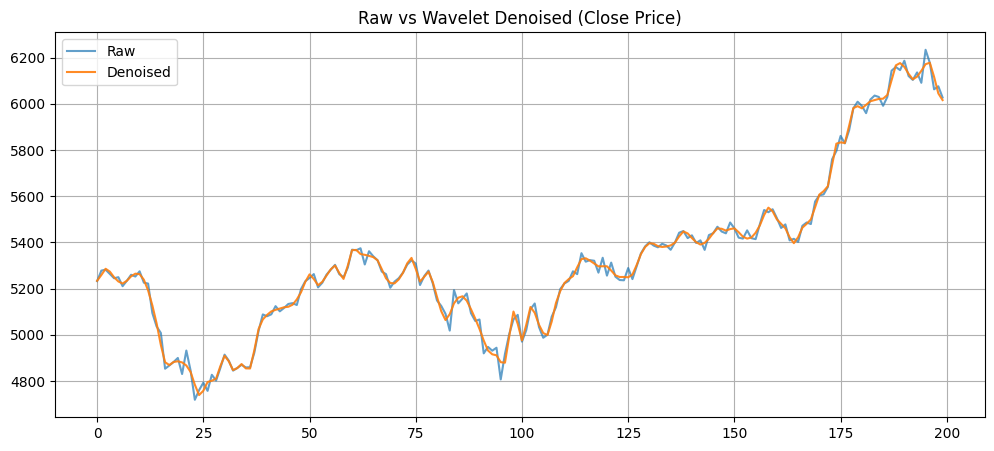

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df_raw["Close"].values[:200], label="Raw", alpha=0.7)
plt.plot(df_denoised["Close"].values[:200], label="Denoised", alpha=0.9)

plt.title("Raw vs Wavelet Denoised (Close Price)")
plt.legend()
plt.grid(True)
plt.show()

# 3. Feature Scaling + Target Preparation

## 3.1 Define Columns

In [ ]:
feature_cols = ["Open", "High", "Low", "Close"]
target_col   = "Close"

## 3.2 Scale DENOISED Data

In [ ]:
feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

X_features = feature_scaler.fit_transform(df_denoised[feature_cols])
y_target   = target_scaler.fit_transform(df_denoised[[target_col]])

## 3.3 Scale RAW Data

In [ ]:
feature_scaler_raw = MinMaxScaler()
target_scaler_raw  = MinMaxScaler()

X_features_raw = feature_scaler_raw.fit_transform(df_raw[feature_cols])
y_target_raw   = target_scaler_raw.fit_transform(df_raw[[target_col]])

## 3.4 Check Shapes

In [ ]:
print("DENOISED X:", X_features.shape)
print("DENOISED y:", y_target.shape)

print("RAW X:", X_features_raw.shape)
print("RAW y:", y_target_raw.shape)

DENOISED X: (3434, 4)
DENOISED y: (3434, 1)
RAW X: (3434, 4)
RAW y: (3434, 1)


## 3.5 Check Scaling Range

In [ ]:
print("Min (Denoised):", X_features.min(), "Max:", X_features.max())
print("Min (Raw):", X_features_raw.min(), "Max:", X_features_raw.max())

Min (Denoised): 0.0 Max: 1.0
Min (Raw): 0.0 Max: 1.0


# 4. Create Sliding Windows (Time-Series Sequences)

## 4.1 Define Window Size

In [ ]:
WINDOW = 20

## 4.2 Create Window Function

In [ ]:
def create_windows(X, y, window):
    Xs, ys = [], []

    for i in range(window, len(X)):
        Xs.append(X[i-window:i])  # past 'window' days
        ys.append(y[i])           # next day value

    return np.array(Xs), np.array(ys)

## 4.3 Apply on DENOISED Data

In [ ]:
X_all, y_all = create_windows(X_features, y_target, WINDOW)

## 4.4 Apply on RAW Data

In [ ]:
X_all_raw, y_all_raw = create_windows(X_features_raw, y_target_raw, WINDOW)

## 4.5 Check Shapes

In [ ]:
print("DENOISED X:", X_all.shape)
print("DENOISED y:", y_all.shape)

print("RAW X:", X_all_raw.shape)
print("RAW y:", y_all_raw.shape)

DENOISED X: (3414, 20, 4)
DENOISED y: (3414, 1)
RAW X: (3414, 20, 4)
RAW y: (3414, 1)


In [ ]:
print("One sample input shape:", X_all[0].shape)
print("One target:", y_all[0])

One sample input shape: (20, 4)
One target: [0.01755993]


# 5. Train / Validation / Test Split

## 5.1 Compute Split Indices

In [ ]:
n = len(X_all)

train_end = int(0.60 * n)
val_end   = int(0.75 * n)

## 5.2 Split DENOISED Data

In [ ]:
X_train = X_all[:train_end]
X_val   = X_all[train_end:val_end]
X_test  = X_all[val_end:]

y_train = y_all[:train_end]
y_val   = y_all[train_end:val_end]
y_test  = y_all[val_end:]

## 5.3 Split RAW Data

In [ ]:
X_train_raw = X_all_raw[:train_end]
X_val_raw   = X_all_raw[train_end:val_end]
X_test_raw  = X_all_raw[val_end:]

y_train_raw = y_all_raw[:train_end]
y_val_raw   = y_all_raw[train_end:val_end]
y_test_raw  = y_all_raw[val_end:]

## 5.4 Check Shapes

In [ ]:
print("DENOISED:")
print(X_train.shape, X_val.shape, X_test.shape)

print("\nRAW:")
print(X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)

DENOISED:
(2048, 20, 4) (512, 20, 4) (854, 20, 4)

RAW:
(2048, 20, 4) (512, 20, 4) (854, 20, 4)


## 5.5 Sanity Check

In [ ]:
print("Train last index:", train_end)
print("Validation last index:", val_end)
print("Total samples:", n)

Train last index: 2048
Validation last index: 2560
Total samples: 3414


In [ ]:
print("RAW Close sample:", df_raw["Close"].values[:5])
print("DENOISED Close sample:", df_denoised["Close"].values[:5])

RAW Close sample: [[5232.20019531]
 [5277.89990234]
 [5281.79980469]
 [5263.10009766]
 [5244.75      ]]
DENOISED Close sample: [[5233.74804642]
 [5258.79182175]
 [5285.830178  ]
 [5273.37093984]
 [5249.00318143]]


# 6. Build LSTM Model

## 6.1 Define LSTM Model

In [ ]:
def build_lstm(input_shape):
    inp = Input(shape=input_shape)

    x = LSTM(64, activation="tanh", return_sequences=True)(inp)
    x = Dropout(0.1)(x)

    x = LSTM(64, activation="tanh")(x)
    x = Dropout(0.1)(x)

    x = Dense(32, activation="tanh")(x)
    out = Dense(1)(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="mse"
    )

    return model

## 6.2 Build Model Instance

In [ ]:
lstm = build_lstm((WINDOW, 4))

## 6.3 Model Summary

In [ ]:
lstm.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 20, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 20, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,801 (206.25 KB)

 Trainable params: 52,801 (206.25 KB)

 Non-trainable params: 0 (0.00 B)

## 6.4 Define Early Stopping

In [ ]:
cb = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# 7. Train LSTM (RAW vs DENOISED)

## 7.1 Create Separate Models

In [ ]:
lstm_raw = build_lstm((WINDOW, 4))
lstm     = build_lstm((WINDOW, 4))

## 7.2 Train on RAW Data

In [ ]:
print("\nTraining LSTM on RAW data...")

lstm_raw.fit(
    X_train_raw, y_train_raw,
    validation_data=(X_val_raw, y_val_raw),
    epochs=100,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)


Training LSTM on RAW data...
Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - loss: 0.0016 - val_loss: 6.5941e-04
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 3.2395e-04 - val_loss: 5.3677e-04
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 2.9408e-04 - val_loss: 5.5070e-04
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.7879e-04 - val_loss: 4.9915e-04
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.4620e-04 - val_loss: 4.9946e-04
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 2.2642e-04 - val_loss: 5.3324e-04
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.2129e-04 - val_loss: 4.7875e-04
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.1988e-04 - val_loss: 4.7305e-04
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 1.9849e-04 - val_loss: 4.6636e-04
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 1.9682e-04 - val_loss: 4.9826e-04
Epoch 11/100
64/64 ━━━━━━━━━━━━━

## 7.3 Train on DENOISED Data

In [ ]:
print("\nTraining LSTM on DENOISED data...")

lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)


Training LSTM on DENOISED data...
Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0048 - val_loss: 0.0019
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 4.6691e-04 - val_loss: 6.5804e-04
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 3.6359e-04 - val_loss: 6.6547e-04
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.2046e-04 - val_loss: 6.6236e-04
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.2143e-04 - val_loss: 6.2858e-04
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 3.1541e-04 - val_loss: 6.7657e-04
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.8576e-04 - val_loss: 6.1697e-04
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 2.7298e-04 - val_loss: 6.5616e-04
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 2.8602e-04 - val_loss: 5.8140e-04
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 2.7502e-04 - val_loss: 6.0367e-04


## 7.4 Generate Predictions

In [ ]:
# RAW predictions
lstm_pred_raw = lstm_raw.predict(X_test_raw)

# DENOISED predictions
lstm_pred = lstm.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


## 7.5 Store Ground Truth

In [ ]:
y_true_raw = y_test_raw
y_true     = y_test

## 7.6 Evaluation Function

In [ ]:
def evaluate(model_name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f"\n=== {model_name} ===")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

## 7.7 Evaluate LSTM

In [ ]:
evaluate("LSTM RAW", y_true_raw, lstm_pred_raw)
evaluate("LSTM DENOISED", y_true, lstm_pred)


=== LSTM RAW ===
MSE : 0.0003235857518174783
RMSE: 0.017988489425671026
MAE : 0.01489441440617011
R²  : 0.9828641519048708

=== LSTM DENOISED ===
MSE : 0.025506041287907098
RMSE: 0.159706109112667
MAE : 0.14909831951594096
R²  : -0.34587217860002584


# 8. Build & Train CNN Model

## 8.1 Define CNN Model

In [ ]:
def build_cnn(input_shape):
    inp = Input(shape=input_shape)

    x = Conv1D(64, kernel_size=2, activation="relu", padding="causal")(inp)
    x = Conv1D(64, kernel_size=2, activation="relu", padding="causal")(x)

    x = MaxPooling1D(pool_size=2)(x)
    x = Flatten()(x)

    x = Dense(64, activation="relu")(x)
    out = Dense(1)(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

## 8.2 Create Model Instances

In [ ]:
cnn_raw = build_cnn((WINDOW, 4))
cnn     = build_cnn((WINDOW, 4))

## 8.3 Train on RAW Data

In [ ]:
print("\nTraining CNN on RAW data...")

cnn_raw.fit(
    X_train_raw, y_train_raw,
    validation_data=(X_val_raw, y_val_raw),
    epochs=100,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)


Training CNN on RAW data...
Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0016 - val_loss: 9.3981e-04
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1823e-04 - val_loss: 8.6886e-04
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.3956e-05 - val_loss: 7.7525e-04
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.4689e-05 - val_loss: 5.1877e-04
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.0907e-05 - val_loss: 3.4339e-04
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.3018e-05 - val_loss: 3.4383e-04
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7796e-05 - val_loss: 2.7115e-04
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2548e-05 - val_loss: 2.1769e-04
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9299e-05 - val_loss: 1.8773e-04
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7912e-05 - val_loss: 1.8295e-04
Epoch 11/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6

## 8.4 Train on DENOISED Data

In [ ]:
print("\nTraining CNN on DENOISED data...")

cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[cb],
    verbose=1
)


Training CNN on DENOISED data...
Epoch 1/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.2917e-04 - val_loss: 6.5129e-04
Epoch 2/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.1028e-05 - val_loss: 5.5972e-04
Epoch 3/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.5370e-05 - val_loss: 5.3385e-04
Epoch 4/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.8321e-05 - val_loss: 4.5720e-04
Epoch 5/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0834e-05 - val_loss: 3.5095e-04
Epoch 6/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.6047e-05 - val_loss: 2.9028e-04
Epoch 7/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.1090e-05 - val_loss: 2.9635e-04
Epoch 8/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.6841e-05 - val_loss: 1.7084e-04
Epoch 9/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9672e-05 - val_loss: 1.8283e-04
Epoch 10/100
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.9360e-05 - val_loss: 2.2738e-04


## 8.5 Predictions

In [ ]:
cnn_pred_raw = cnn_raw.predict(X_test_raw)
cnn_pred     = cnn.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


## 8.6 Evaluate CNN

In [ ]:
evaluate("CNN RAW", y_true_raw, cnn_pred_raw)
evaluate("CNN DENOISED", y_true, cnn_pred)


=== CNN RAW ===
MSE : 0.0002759486786823828
RMSE: 0.016611703063875865
MAE : 0.013645718835530351
R²  : 0.9853868267888997

=== CNN DENOISED ===
MSE : 0.0005189117354383376
RMSE: 0.022779634225297333
MAE : 0.01831332313407158
R²  : 0.9726186882553729


# 9. Build & Train TCN (Temporal Convolutional Network)

## 9.1 Define TCN Block

In [ ]:
def tcn_block(x, filters, k=2, rate=1, drop=0.1):
    c1 = Conv1D(filters, k, dilation_rate=rate,
                activation="relu", padding="causal")(x)
    c1 = Dropout(drop)(c1)

    c2 = Conv1D(filters, k, dilation_rate=rate,
                activation="relu", padding="causal")(c1)

    # Residual connection
    if x.shape[-1] != filters:
        x = Conv1D(filters, 1, padding="same")(x)

    out = Add()([c2, x])
    return Activation("relu")(out)

## 9.2 Build TCN Model

In [ ]:
def build_tcn(input_shape):
    inp = Input(shape=input_shape)
    x = inp

    # Increasing dilation rates
    for d in [1, 2, 4]:
        x = tcn_block(x, filters=64, k=2, rate=d)

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x)
    out = Dense(1)(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="mse"
    )

    return model

## 9.3 Create Model Instances

In [ ]:
tcn_raw = build_tcn((WINDOW, 4))
tcn     = build_tcn((WINDOW, 4))

## 9.4 Train on RAW Data

In [ ]:
print("\nTraining TCN on RAW data...")

tcn_raw.fit(
    X_train_raw, y_train_raw,
    validation_data=(X_val_raw, y_val_raw),
    epochs=100,
    batch_size=64,
    callbacks=[cb],
    verbose=1
)


Training TCN on RAW data...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.7382e-04 - val_loss: 8.8772e-04
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.4346e-04 - val_loss: 8.7667e-04
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.4010e-04 - val_loss: 8.4833e-04
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.3709e-04 - val_loss: 8.4218e-04
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.3450e-04 - val_loss: 8.3135e-04
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.3517e-04 - val_loss: 8.2363e-04
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.3382e-04 - val_loss: 8.1341e-04
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.3045e-04 - val_loss: 8.0580e-04
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.3200e-04 - val_loss: 7.9880e-04


## 9.5 Train on DENOISED Data

In [ ]:
print("\nTraining TCN on DENOISED data...")

tcn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[cb],
    verbose=1
)


Training TCN on DENOISED data...
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0045 - val_loss: 0.0010
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.5213e-04 - val_loss: 8.6771e-04
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.6317e-04 - val_loss: 8.5451e-04
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.4878e-04 - val_loss: 8.5140e-04
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.4660e-04 - val_loss: 8.5551e-04
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.4532e-04 - val_loss: 8.6382e-04
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.4087e-04 - val_loss: 8.5934e-04
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.3786e-04 - val_loss: 8.5904e-04
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.3943e-04 - val_loss: 8.5601e-04
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.3886e-04 - val_loss: 8.4874e-04


## 9.6 Predictions

In [ ]:
tcn_pred_raw = tcn_raw.predict(X_test_raw)
tcn_pred     = tcn.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


## 9.7 Evaluate TCN

In [ ]:
evaluate("TCN RAW", y_true_raw, tcn_pred_raw)
evaluate("TCN DENOISED", y_true, tcn_pred)


=== TCN RAW ===
MSE : 0.0032295137901955885
RMSE: 0.056828811268542195
MAE : 0.05082559643749225
R²  : 0.8289774583117857

=== TCN DENOISED ===
MSE : 0.0010873805330589659
RMSE: 0.032975453492847764
MAE : 0.026614364237680727
R²  : 0.9426224089235993


# 10. Ensemble (Stacking Model)

## 10.1 Create Meta Features

In [ ]:
X_meta_train = np.hstack([
    lstm_raw.predict(X_train_raw),   # RAW
    cnn.predict(X_train),            # DENOISED
    tcn.predict(X_train)             # DENOISED (or raw if better)
])

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


## 10.2 Create Test Meta Features

In [ ]:
X_meta_test = np.hstack([
    lstm_pred_raw,   # RAW
    cnn_pred,        # DENOISED
    tcn_pred         # DENOISED
])

## 10.3 Train Meta Model (Linear Regression)

In [ ]:
meta = LinearRegression()
meta.fit(X_meta_train, y_train)

LinearRegression()

## 10.4 Prediction

In [ ]:
ensemble_pred = meta.predict(X_meta_test).reshape(-1, 1)

## 10.5 Evaluate Ensemble

In [ ]:
evaluate("Ensemble", y_true, ensemble_pred)


=== Ensemble ===
MSE : 0.0003299615429812557
RMSE: 0.018164843599141053
MAE : 0.015093031114801697
R²  : 0.9825889852645633


## 10.6 Check Model Weights

In [ ]:
print("\n===== Ensemble Weights =====")
print(f"LSTM (RAW) weight : {meta.coef_[0][0]:.6f}")
print(f"CNN (DENOISED)   : {meta.coef_[0][1]:.6f}")
print(f"TCN              : {meta.coef_[0][2]:.6f}")
print(f"Bias             : {meta.intercept_[0]:.6f}")


===== Ensemble Weights =====
LSTM (RAW) weight : 1.246300
CNN (DENOISED)   : -0.522805
TCN              : 0.302962
Bias             : -0.012330


# 11. Visualization + Final Comparison

## 11.1 Store Model Names

In [ ]:
models = ["LSTM", "CNN", "TCN", "Ensemble"]

## 11.2 Compute Metrics for All Models

In [ ]:
def compute_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

In [ ]:
metrics = {"MSE": [], "RMSE": [], "MAE": [], "R2": []}

preds = [
    lstm_pred_raw,   # LSTM (RAW)
    cnn_pred,        # CNN (DENOISED)
    tcn_pred,        # TCN
    ensemble_pred    # Ensemble
]

for p in preds:
    m = compute_metrics(y_true, p)
    for (k, v) in zip(metrics.keys(), m):
        metrics[k].append(v)

## 11.3 Bar Graph Comparison

In [ ]:
def plot_compare(metric_name):
    values = metrics[metric_name]

    x = np.arange(len(models))

    plt.figure(figsize=(8,5))
    plt.bar(x, values)

    plt.title(f"{metric_name} Comparison Across Models", fontsize=14)
    plt.xlabel("Models")
    plt.ylabel(metric_name)
    plt.xticks(x, models)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Value labels
    for i, v in enumerate(values):
        plt.text(i, v + (v * 0.05 + 1e-6), f"{v:.4f}", ha='center')

    plt.show()

## 11.4 Plot All Metrics

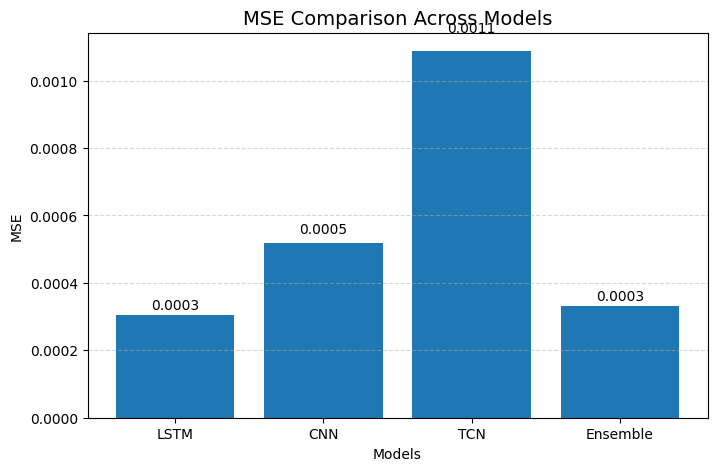

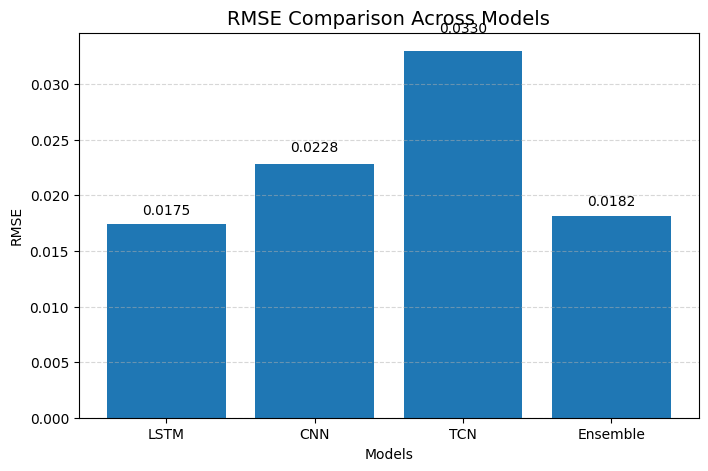

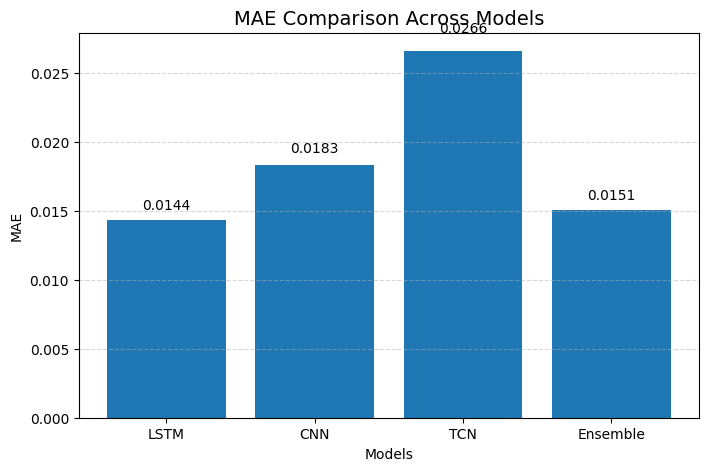

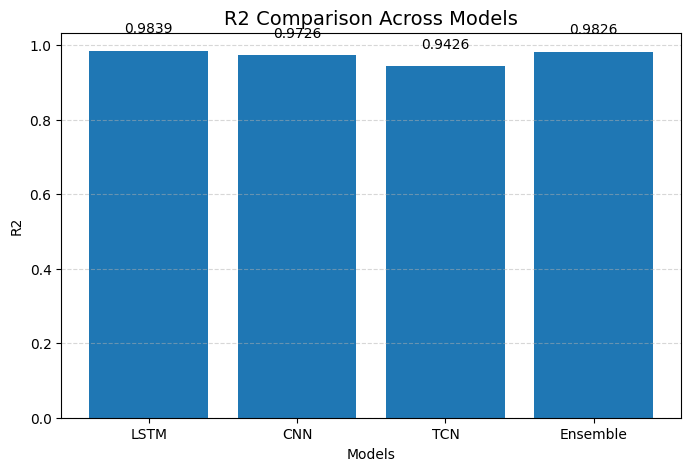

In [ ]:
plot_compare("MSE")
plot_compare("RMSE")
plot_compare("MAE")
plot_compare("R2")

## 11.4 Actual vs Predicted Plot

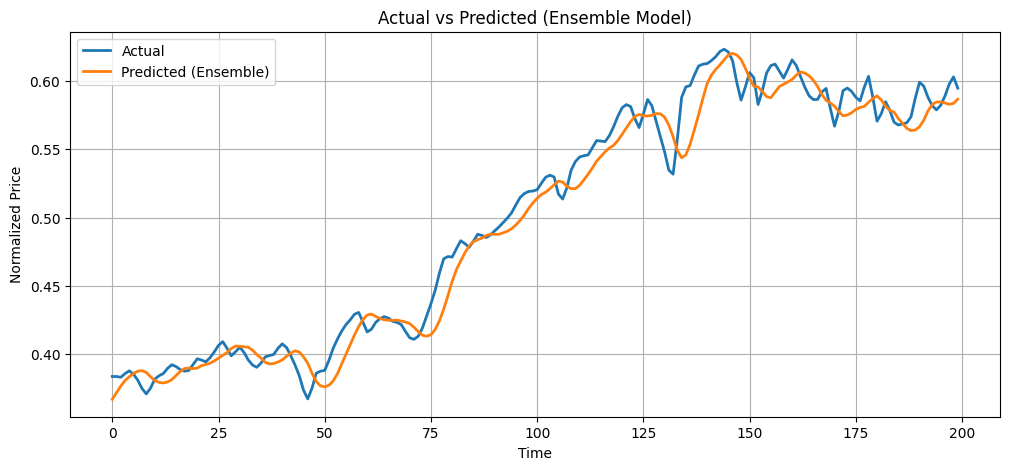

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_true[:200], label="Actual", linewidth=2)
plt.plot(ensemble_pred[:200], label="Predicted (Ensemble)", linewidth=2)

plt.title("Actual vs Predicted (Ensemble Model)")
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)

plt.show()

## 11.5 Save Predictions

In [ ]:
results_df = pd.DataFrame({
    "Actual": y_true.flatten(),
    "LSTM": lstm_pred_raw.flatten(),
    "CNN": cnn_pred.flatten(),
    "TCN": tcn_pred.flatten(),
    "Ensemble": ensemble_pred.flatten()
})

results_df.to_csv(f"{project_path}/predictions.csv", index=False)

## 11.6 Save Models

In [ ]:
lstm_raw.save(f"{project_path}/lstm_model.keras")
cnn.save(f"{project_path}/cnn_model.keras")
tcn.save(f"{project_path}/tcn_model.keras")

## 11.7 Save Scalers

In [ ]:
import joblib

joblib.dump(feature_scaler, f"{project_path}/feature_scaler.pkl")
joblib.dump(target_scaler, f"{project_path}/target_scaler.pkl")

['/content/drive/MyDrive/Stock_Prediction_Project/target_scaler.pkl']